# Importações

### Bibliotecas Padrão

In [2]:
import numpy             as np
import pandas            as pd
import matplotlib.pyplot as plt
import xgboost           as xgb

import pickle
import concurrent.futures
import unidecode
import os
import sys

from datetime                 import datetime
from concurrent               import futures
from scipy.spatial            import cKDTree
from unidecode                import unidecode
from sklearn.model_selection  import train_test_split, cross_val_score,KFold
from sklearn.metrics          import mean_absolute_error, mean_squared_error,make_scorer

pd.options.display.float_format = '{:,.5f}'.format
pd.set_option('display.max_rows', None)

### Bibliotecas Próprias

In [3]:
# Primeiro, defina o caminho do arquivo

sys.path.append(r'D:\Drive\Codigos bee6\bee6_notebooks\bee6_geral')

# Agora importe as classes
from aplica_dados_geo import (
    CalculoDistanciaTransporte,TrataDelegacias,
    AgregaIptuCep,MesclaDadosMunicipais)

### Arquivos Locais

In [4]:
# Define the paths to search for files
paths = [
    r'D:\Drive\Codigos bee6\bee6_arquivos\urban_space\Tratados',
    r'D:\Drive\Codigos bee6\bee6_arquivos\bee6_geral\Tratados\Sao Paulo']

# Define a function to read a file
def read_file(file_path):
    if file_path.endswith('.parquet'):
        return pd.read_parquet(file_path)
    elif file_path.endswith('.csv'):
        return pd.read_csv(file_path)
    else:
        raise ValueError(f"Unsupported file format for {file_path}")

# Function to process files in a directory
def process_directory(directory):
    dataframes = {}
    for filename in os.listdir(directory):
        file_path = os.path.join(directory, filename)
        if os.path.isfile(file_path) and (filename.endswith('.csv') or filename.endswith('.parquet')):
            df = read_file(file_path)
            name, _ = os.path.splitext(filename)
            dataframes[name] = df
    return dataframes

# Create a ThreadPoolExecutor to read files in parallel
all_dataframes = {}
with concurrent.futures.ThreadPoolExecutor() as executor:
    # Use list comprehension to process directories in parallel
    futures = [executor.submit(process_directory, path) for path in paths]
    for future in concurrent.futures.as_completed(futures):
        directory_dataframes = future.result()
        all_dataframes.update(directory_dataframes)

# Define DataFrames dynamically based on file names
globals().update(all_dataframes)

# Filtra apenas pros tipos de propriedade mais comuns em sp, tirando terrenos, galpões e etc...
vivareal_venda_sp['tipo'] = vivareal_venda_sp['tipo'].str.replace("'", "")
vivareal_venda_sp['subtipo'] = vivareal_venda_sp['subtipo'].str.replace("'", "")
vivareal_venda_sp['tipo_uso'] = vivareal_venda_sp['tipo_uso'].str.replace("'", "")
vivareal_venda_sp = vivareal_venda_sp.query("tipo in ['APARTMENT', 'HOME', 'PENTHOUSE', 'CONDOMINIUM', 'OFFICE', 'FLAT']")

# Análise Exploratória

In [5]:
### Eu posso me limitar apenas A
## Preços de venda de residenciais na cidade de SP, para simplificar o modelo
### Obter, através da Urban, preços reais de venda de imoveis para ajuste do meu modelo, usar multi-task learning no xgboost
# ou seja, poucas instancias Y reais e mtas proxy, stacking learning

# Verificar formas de obter mais dados reais de venda (com julio, rica, cartorios) # sempre corrigir pela data de venda

# alias, como as diferentes datas de venda existem, posso calibrar isso para considerar na timeseries do fipezap!

# pesquisar monte carlo tb

# Atualizações

# Investigar melhor imoveis duplicados com preços diferentes
#- learning_rate o incremento de peso a cada iteração (aprende padroes especificos), mais alto dá saltos maiores na funcao
# Estudar função de perda de diferentes combinaçoes de hiperparâmetros e fazer validação cruzada

# Estudos

#- metodo de newton-rhapson
#- serie de taylor novamente
# Grafos sao a base das arvores de decisão

tipo                   object
subtipo                object
tipo_uso               object
municipio              object
cep                    object
area_construida_m2     object
area_total_m2         float64
condominio_mensal      object
iptu_anual             object
num_quartos            object
num_suites             object
num_banheiros          object
num_vagas_est          object
preco                 float64
tipo_negocio           object
idimovel                int64
lat_long               object
dtype: object

# Tratamento dos Dados

### Aplica as classes de transformação

In [8]:
# Fazer analise exploratoria aqui

# Primeiro atribuo a Lat e Long de cada delegacia (que não dá match exato com os Distritos), depois, calculo qual 
# o distrito mais próximo dessa delegacia, a limitação é que uma delegacia pode estar na borda de um distrito,
# sendo mais relacionada as ocorrências deste distrito do que do próprio (baseado no centro do polígono do distrito)
# mas é o que tem pra hoje. Se tivermos mais de uma delegacia mapeada pra um mesmo distrito, somo os dados.
# Usarei apenas a coluna de Registros_Policiais, sem considerar os subtipos de ocorrência, para facilitar a análise
# Os dados da delegacia são de 2022, e precisam ser normalizados pela pop de cada distrito (de 2010), o que não é o ideal, mas
# pode servir de aproximação. No final, atribuo, para cada cep de SP, um registro policial com base no distrito em que o CEP está inserido
bo_distrito = TrataDelegacias(delegacias, distrito_latlong, pop_distrito_sp, ceps_sp).process()

# O codigo, com base na informação de pontos de onibus/terminais/estacao de trem e metro fornecidas pela prefeitura, calcula a distância deste 
# para cada Cep único da cidade de SP, e retorna a distância, em metros, de cada um dos ceps em relação aos modais de transporte.
cep_calculo_transportes = CalculoDistanciaTransporte(ceps_sp, estacao_metro, ponto_onibus, estacao_trem, terminal_onibus).process()

# Aqui tenho a informação de cada um dos iptus registrados na prefeitura para o ano de 2023. Nesse caso, como nao posso mapear cada imovel
# com seu respectivo IPTU, irei usar a info agregada dos bairros. Para variaveis continuas, farei a média por CEP, para categóricas, primeiro
# realizarei o frequency encoding, que atribui para cada valor unico a quantidade de ocorrencias daquela categoria, e depois, soma todos os valores
# para cada cep.
iptu = AgregaIptuCep(iptu_estat_sp).process()

# Agrega os seguintes dados na base de imoveis para treino
# bo_distrito: proporção de ocorrências pelo total de habitantes
# cep_calculo_transportes: distância de cada cep em relação aos 4 modais de transporte mais próximos
# iptu: dados médios das características das edificações daquele cep
# estat_udh: dados sociais referentes a um determinado udh, atribuido a cada cep
imoveis_treino = MesclaDadosMunicipais(vivareal_venda_sp, estat_udh, iptu, cep_calculo_transportes, bo_distrito, ceps_sp).process()

D:\Drive\Codigos bee6\bee6_notebooks\bee6_geral\aplica_dados_geo.py:201: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.cep.rename(columns={


### Análise Exploratória

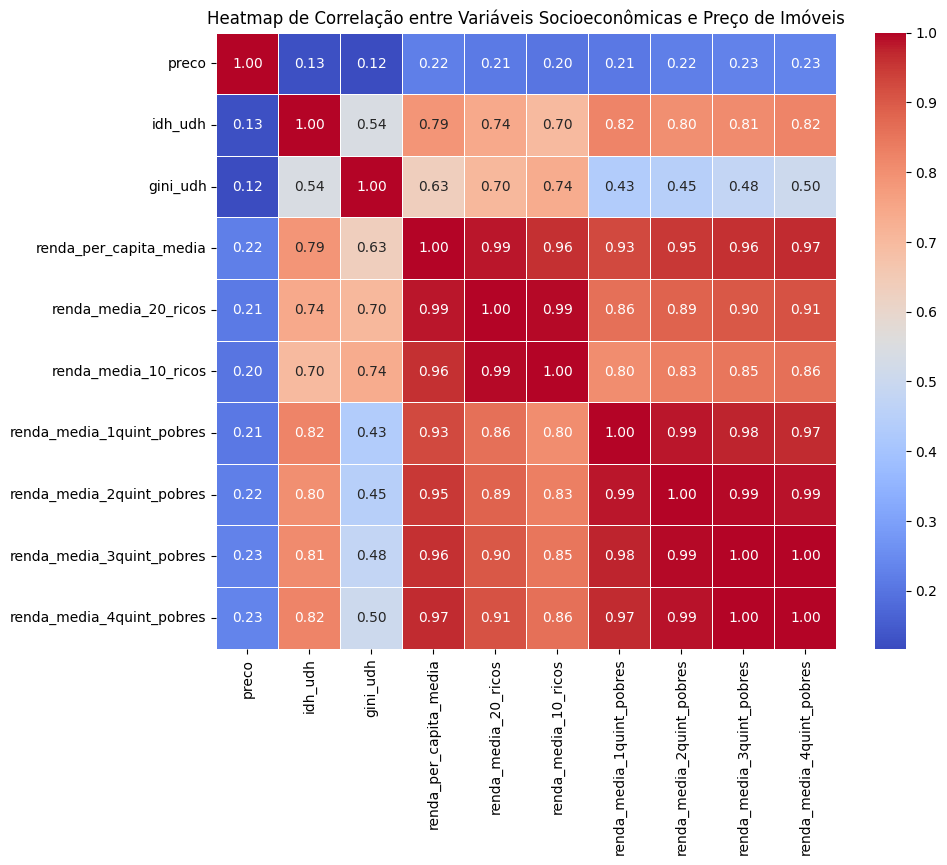

                            preco  idh_udh  gini_udh  renda_per_capita_media  \
preco                     1.00000  0.12739   0.11705                 0.22349   
idh_udh                   0.12739  1.00000   0.54368                 0.78902   
gini_udh                  0.11705  0.54368   1.00000                 0.63430   
renda_per_capita_media    0.22349  0.78902   0.63430                 1.00000   
renda_media_20_ricos      0.21240  0.74240   0.70470                 0.98592   
renda_media_10_ricos      0.19983  0.69951   0.73726                 0.96136   
renda_media_1quint_pobres 0.20750  0.82389   0.43384                 0.92594   
renda_media_2quint_pobres 0.22122  0.80071   0.44625                 0.94918   
renda_media_3quint_pobres 0.22918  0.80862   0.47658                 0.96149   
renda_media_4quint_pobres 0.23105  0.82133   0.50358                 0.96711   

                           renda_media_20_ricos  renda_media_10_ricos  \
preco                                   0.2124

In [9]:
# Importando bibliotecas necessárias
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


# Selecionando as colunas de interesse
# Vamos escolher variáveis socioeconômicas e o preço dos imóveis
cols_of_interest = [
    'preco', 'idh_udh', 'gini_udh', 'renda_per_capita_media',
    'renda_media_20_ricos', 'renda_media_10_ricos', 'renda_media_1quint_pobres', 
    'renda_media_2quint_pobres', 'renda_media_3quint_pobres', 'renda_media_4quint_pobres'
]

# Filtrando o dataframe para essas colunas
df_filtered = imoveis_treino[cols_of_interest]

# Convertendo strings para numéricos, se necessário (caso haja dados inválidos)
# Isso pode variar conforme a estrutura dos dados, ajuste conforme necessário
df_filtered = df_filtered.apply(pd.to_numeric, errors='coerce')

# Remover linhas com valores faltantes
df_filtered = df_filtered.dropna()

# Calculando a matriz de correlação
correlation_matrix = df_filtered.corr()

# Plotando a matriz de correlação usando um heatmap do seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Heatmap de Correlação entre Variáveis Socioeconômicas e Preço de Imóveis')
plt.show()

# Exibir a matriz de correlação
print(correlation_matrix)


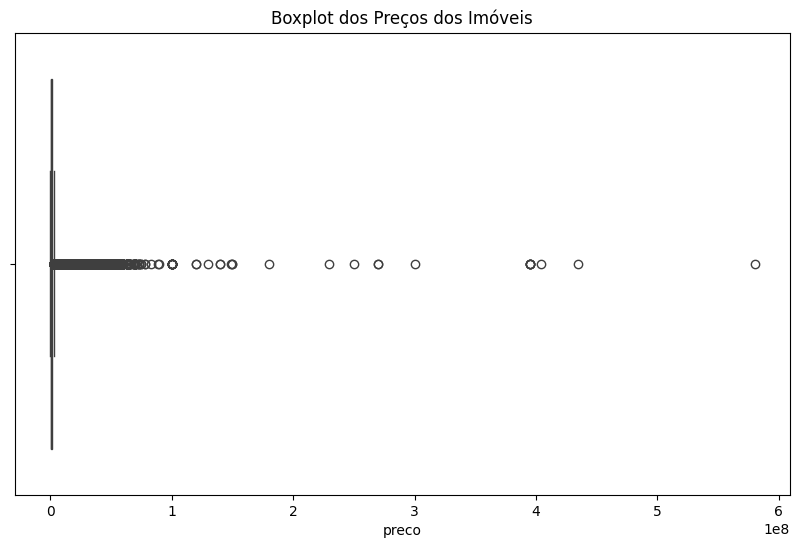

Outliers detectados: 107885
                    preco
91        3,396,000.00000
143       2,915,000.00000
159       2,999,998.00000
163       3,399,999.00000
168       3,000,000.00000
174       3,200,000.00000
190       6,555,000.00000
193       3,000,000.00000
201       3,690,000.00000
221       3,200,000.00000
250       2,925,000.00000
265       3,690,000.00000
278       3,950,000.00000
340       4,000,000.00000
383       3,520,000.00000
385       4,200,000.00000
397       3,600,000.00000
416       2,982,000.00000
422       4,300,000.00000
463       3,500,000.00000
467       3,800,000.00000
518       3,730,000.00000
571       3,200,000.00000
572       3,700,000.00000
578       5,000,000.00000
629       3,199,998.00000
641       3,400,000.00000
649       3,200,000.00000
657       3,200,000.00000
668       3,180,000.00000
681       4,228,000.00000
694       3,500,000.00000
699       3,180,000.00000
706       4,600,000.00000
740       3,800,000.00000
753       2,968,000.00000
826       

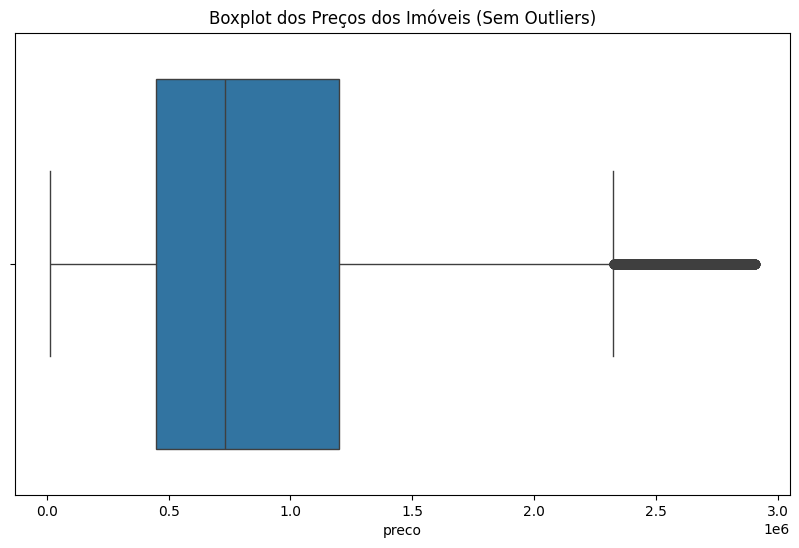

In [10]:
# Selecionando a coluna de preço
df_preco = imoveis_treino[['preco']]

# Remover linhas com valores faltantes na coluna 'preco'
df_preco = df_preco.dropna()

# Visualizando a distribuição dos preços com um boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_preco, x='preco')
plt.title('Boxplot dos Preços dos Imóveis')
plt.show()

# Calculando os quartis e o IQR
Q1 = df_preco['preco'].quantile(0.25)  # Primeiro quartil (25%)
Q3 = df_preco['preco'].quantile(0.75)  # Terceiro quartil (75%)
IQR = Q3 - Q1                          # Intervalo Interquartil

# Definindo os limites inferior e superior para detectar outliers
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# Identificando os outliers
outliers = df_preco[(df_preco['preco'] < limite_inferior) | (df_preco['preco'] > limite_superior)]

# Exibindo os outliers
print(f'Outliers detectados: {len(outliers)}')
print(outliers)

# Filtrando o dataset sem os outliers
df_sem_outliers = df_preco[(df_preco['preco'] >= limite_inferior) & (df_preco['preco'] <= limite_superior)]

# Visualizando a distribuição dos preços após remover os outliers
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_sem_outliers, x='preco')
plt.title('Boxplot dos Preços dos Imóveis (Sem Outliers)')
plt.show()

### Remove outliers e prepara conjunto de dados

In [11]:
def preco_por_m2_e_99_percentil_off(df, preco_col, area_col='area_construida_m2'):
    # Converte as colunas para numérico, forçando erros para NaN
    df[preco_col] = pd.to_numeric(df[preco_col], errors='coerce')
    df[area_col] = pd.to_numeric(df[area_col], errors='coerce')
    
    # Cria a nova coluna de preço por m²
    df['preco_por_m2'] = df[preco_col] / df[area_col]
    
    # Remove valores infinitos e nulos após a divisão
    df['preco_por_m2'].replace([np.inf, -np.inf], np.nan, inplace=True)
    df.dropna(subset=['preco_por_m2'], inplace=True)
    
    # Calcula o percentil 99 do preço por m²
    percentile_99 = df['preco_por_m2'].quantile(0.99)
    
    # Filtra os dados removendo os outliers
    df = df[df['preco_por_m2'] <= percentile_99]
    
    return df

# Aplicando a função de normalização e remoção de outliers
imoveis_treino = preco_por_m2_e_99_percentil_off(imoveis_treino, 'preco')

colunas_para_remover = ['municipio', 'cep', 'tipo_negocio', 'lat_long', 'distrito', 'udh', 'idimovel','preco','tipo','subtipo','tipo_uso']

# Removendo as colunas do DataFrame
imoveis_treino = imoveis_treino.drop(columns=colunas_para_remover)

C:\Users\guici\AppData\Local\Temp\ipykernel_19720\3662020906.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['preco_por_m2'].replace([np.inf, -np.inf], np.nan, inplace=True)


### Faz o split de treino e teste

In [12]:
# Definindo X e y
X = imoveis_treino.drop(columns=['preco_por_m2'])
y = imoveis_treino['preco_por_m2']

# Dividindo os dados em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Treinamento do Modelo e Resultados

### Define Função

In [15]:
# Diferença de bagging e boosting

# Bagging: Usado mais comumente em random forests
# "Aprendedores Fracos" (como árvores) são construídos indepentes uns dos outros e são combinados por um processo de média determinístico
# Foco em modelo com o menos variância

# Boosting: Usado mais comumente em xgboost
# "Aprendedores Fracos" são construídos sequencialmente e combinados por um processo determinístico
# Foco em modelos com menos viés (também reduz variância)

# Como é construída a árvore?

# Primeiro, ele faz uma predição simples usando a média, com isso, calcula-se o resíduo, ou a diferença de cada
# ponto em relação a média

# Constrói-se a primeira folha que recebe a equação (similarity score, ou SS)
# (Soma dos resíduos)^2 / hessiana + lambda
# Sendo hessiana = número de resíduos
# Lambda = por padrão 1, é um parâmetro regularizador que reduz a sensitividade das predições

# Técnicas de regularização: Lasso, Ridge, Elastic Net
# Um modelo pode possuir mais ou menos graus de liberdade, o que seria, no caso de um polinômio, o número de termos, ou seu grau
# Quanto mais graus de liberdade, mais possibilidades o modelo de ajustar sua função aos pesos das variáveis independentes. Quando temos
# um polinomio de grau muito elevado, isso pode overfittar os dados, ou seja, o modelo pode ajustar seus pesos para buscar pontos individuais,
# mesmo que esses pontos contenham ruído nos dados, fazendo-o ser um mal generalizador.
# Técnicas de regularização, como as estudadas agora, são utilizadas para limitar o peso dado as variáveis indepedentes num polinômio de grau n

# Ridge regression é adicionada ao MSE e força o algoritmo a manter os pesos o menor possível, definido por alpha.
# Alpha será o termo de regularização adicionado ao MSE, se 0, não faz efeito, se muito alto, o termo tende a colocar os valores
# próximos a média do conjunto

  #'MAE': [mae], # Erro absoluto médio: É a média do módulo das diferenças.
  # Uma métrica simples que indica o tamanho do erro médio, porém, náo penaliza erros muito grandes, já que
  # não faz o quadrado dos erros, não é sensível a outlie
  #'MSE': [mse], # Erro quadrático médio. Equivalente ao MAE, porém, é a média
  # do quadrado das diferenças. Isso faz com que erros maiores sejam amplificados, tornando  uma métrica útil
  # quando temos menos tolerância a outliers. Erros maiores tem um impacto desproporcionalmente maior na métric
  #'RMSE': [rmse], # Raiz do MSE. É útil para medir o desvio padrão dos residuais, ou erros
  # É representado na escala original dos dados. Ou seja, o MSE pode trazer valores muito grandes, já que erros em unidades
  # de medida na casa do milhares, quando elevados ao quadrado podem representar números grandes, o RMSE traz de volta a mesma
  # escala tirando a raiz quadra
# 'MAPE': [mape], # Erro absoluto médio em porcentagem: É a versão MAE,porém, em porcentag
#  'MdAPE': [mdape]  # Pega a série de porcentagem de erros do MAPE e retorna a mediana dessas porcentagens
  # dessa maneira, é menos sensível a outliers, uma medida robusta do conjunto como um todo, sem tanta atenção a outliers})

xgb_params = {
    
    # Hiperparâmetros Externos (Como uso de processador, gpu, verbosidade, paralelização, etc...)

    'objective': 'reg:squarederror', # Define o objetivo do modelo, se é classificação ou regressão
    'enable_categorical': True, # Garante que as variáveis categóricas sejam tratadas internamente sem necessidade de pré-processamento
    'verbosity': 0,  # Cala a boca do modelo
    'n_jobs': -1,  # Número de núcleos do CPU para treinar o modelo, -1 usa todos
    'random_state': 42,  # Define a reprodutibilidade de um modelo, setando um valor como seed, ou seja, como gerador de números pseudo-aleatórios
    'gpu_id': -1,  # -1 significa uso do CPU, se a GPU for compatível (nvidia CUDA), setar para 0 (1 em diante para 2 ou mais GPUs)
    'validate_parameters': True,  # Valida se todos os hiperparametros foram preenchidos adequadamente, facilitando o debug
    'predictor': 'gpu_predictor',  # Define se usa GPU ou CPU, se = None, busca automaticamente o melhor,
    'tree_method': 'gpu_hist',  # Utilizes the GPU accelerated histogram algorithm for tree construction

    # Hiperparâmetros internos (Desempenho do modelo em si)
    
    'n_estimators': 3000,  # numero de arvores totais criadas no modelo (no caso de bagging, serão treinadas independentes, em boosting, sequencialmente)
    # um número maior de árvores reforça o modelo, reduzindo underfitting, porém muitas árvores podem fazer com que algumas sejam redundantes e amplifiquem
    # sinais de sobreajuste que antes eram dispersos, mas agora ficam amplificados)

    'max_depth': 6,  # profundidade maximo da arvore q poderá ser atingido (eixo X da árvore, ou seja, crescimento na horizontal), se = None, a arvore
    # se expandirá ate todos os nodos serem puros

    'learning_rate': 0.01,  # Taxa na qual o aprendizado é atualizado durante o treinamento, o tamanho do passo em cada iteração quando se move para o mínimo da
    # função (pense como a velocidade de um carro descendo uma ladeira (ponto mínimo da ladeira é o minimo da função)). Quando uma árvore nova é adicionada, suas 
    # predições são mutiplicadas pela learning rate e adicionadas ao modelo, quanto menor o número, menor a contribuição individual de cada árvore posterior.
    # Um learning rate menor exige mais árvores (n_estimator), isso aumenta o gasto computacional e pode gerar overfitting, porém, pode melhorar os resultados do modelo
    # se ele estiver underfittando. O processo é mais lento, preciso e gradual, aumentando a chance do modelo não ultrapassar o mínimo da função. Podemos imaginar que quanto
    # maior o learning rate, maiores são os "saltos" entre cada iteração, levando a uma maior generalizacão, mas com risco de underfitting, quanto menor, mais granular
    # é cada iteração, mas com risco de overfitting.

    'gamma': None,  # Placeholder for minimum loss reduction
    'subsample': 0.7,  # Placeholder for subsample ratio
    
    'colsample_bytree': 0.7,  # Placeholder for subsample ratio of columns for each tree
    'colsample_byLevel': None,  # Placeholder for subsample ratio of columns for each split
    'colsample_bynode': None,  # Placeholder for subsample ratio of columns for each node

    'reg_lambda': 10,  # L2 ou ridge regression. Ridge regression é uma forma de regularização que funciona da seguinte forma: 
    # MSE representa o erro do nosso modelo, ou o "custo", esse custo é uma função de theta, ou, um vetor dos parâmetros usados no modelo de predição
    # Os parâmetros são os pesos que, por exemplo, multiplicam nossas variáveis independentes e nos gera um vetor de predições. Cada vetor de parâmetros
    # gera um diferente MSE, ou custo. O objetivo aqui é obter vetores de parâmetros que reduzam nosso custo em um processo iterativo, em que buscamos
    # valores menores para a derivada da função MSE. Isso é feito somando o termo de regularização a nossa função de custo, representada por lambda, ou
    # MSE + lambda * parâmetros^2. Se o termo lambda for = 0, efetivamente a regularização não ocorre, porém, lambda pode assumir qualquer valor > 0, 
    # o que ajusta seu termo de regularização na medida que o multiplica pelos parâmetros ao quadrado.
    # Um detalhe importante aqui é que a regularização é somada ao fator de erro, ou seja, na prática está aumentando-o no conjunto de treino, mas o que leva
    # a redução do erro no conjunto de teste.
    # Quando não aplicamos a regularização, os parâmetros possuem mais graus de liberdade para assumir valores, fazendo o modelo seguir de maneira muito próxima
    # o conjunto de treino, podendo capturar ruído nos dados, o famoso overfitting. Quando adicionamos o termo de regularização, estamos introduzindo um viés,
    # encolhendo seus coeficientes, mas diminuindo sua variância, o quanto esses coeficientes se distanciam da média, ou seja, fazendo com que os parâmetros
    # resultantes sejam menos sensíveis a variações internas nos dados. Reduzir a variância é penalizar coeficientes muito grandes, evitando que uma única
    # feature tenha um peso desproporcionamente grande na predição geral, tornando o modelo mais simples e reduzindo a chance dele ser treinado em dados ruidosos.
    # Esse é um conceito geral, que pode ser visualizado em termos de um modelo linear. Em modelos baseados em árvore, o reg_lambda penaliza o peso de árvores
    # individuais.

    'reg_alpha': 1,  # L1 ou Lasso regression, equivalente a ridge regression, porém, o termo de regularização é aplicado ao módulo dos parâmetros, e não
    # ao seu quadrado. Ele pode tender a diminuir os termos a 0, aumentando a esparsidade e fazendo-o ignorar completamente algumas features, o que pode ser
    # relevante se você julga que algumas features podem ser redundantes ou irrelevantes, quanto maior o termo de regularização, maior a tendência da
    # regularização zerar alguns termos. L2, ou ridge, tende a elevar ao quadrado os termos, ou seja, tende a reduzir mais os pesos, porém, sem zerá-los. L1, por
    # poder reduzir termos a zero acaba realizando um tipo de seleção de features.
    # Elastic net é uma combinação dos 2: No geral, ridge é mais indicada quando você deseja manter todos os parametros no modelo, mas com influência mais 
    # suavizada, no caso de muitas features terem um peso moderado a baixo, ao invés de pesos desproporcionalmente grandes
    # Lasso é indicado quando você acredita que apenas um subconjunto das features tem alguma relevância para o modelo, já que tenderia a reduzir o peso de algumas
    # a zero.

    'num_parallel_tree': None,  # Placeholder, set to >1 for boosted random forests
    'min_child_weight': 5,  # Placeholder for minimum sum of instance weight needed in a child
    'early_stopping_rounds': None  # Placeholder for early stopping rounds 
    }

### Executa função e exibe resultado

In [16]:
def train_evaluate_xgb(X, y, categorical_cols, dataset_label, cv_folds=5):
    # Convert categorical columns to 'category' data type
    for col in categorical_cols:
        X[col] = X[col].astype('category')

    # Initialize XGBoost model
    xgb_model = xgb.XGBRegressor(**xgb_params)

    # Define custom scorer for cross-validation
    def custom_scorer(model, X, y):
        y_pred = model.predict(X)
        mae = mean_absolute_error(y, y_pred)
        mse = mean_squared_error(y, y_pred)
        rmse = np.sqrt(mse)
        mape = np.mean(np.abs((y - y_pred) / y)) * 100
        mdape = np.median(np.abs((y - y_pred) / y))
        return mae, mse, rmse, mape, mdape

    # Initialize cross-validator
    kf = KFold(n_splits=cv_folds, shuffle=True, random_state=42)
    
    # Initialize lists to store metrics
    maes, mses, rmses, mapes, mdapes = [], [], [], [], []
    
    # Perform cross-validation
    for train_index, val_index in kf.split(X):
        X_train_cv, X_val_cv = X.iloc[train_index], X.iloc[val_index]
        y_train_cv, y_val_cv = y.iloc[train_index], y.iloc[val_index]
        
        xgb_model.fit(X_train_cv, y_train_cv)
        mae, mse, rmse, mape, mdape = custom_scorer(xgb_model, X_val_cv, y_val_cv)
        
        maes.append(mae)
        mses.append(mse)
        rmses.append(rmse)
        mapes.append(mape)
        mdapes.append(mdape)
    
    # Calculate mean of metrics
    performance_df = pd.DataFrame({
        'Dataset': [dataset_label],
        'MAE': [np.mean(maes)],
        'MSE': [np.mean(mses)],
        'RMSE': [np.mean(rmses)],
        'MAPE': [np.mean(mapes)],
        'MdAPE': [np.mean(mdapes)]})

    # Metadados
    metadados = {
        'data_treinamento': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
        'hiperparametros': xgb_params,
        'features': list(X.columns)  }

    # Armazenar o modelo e os metadados
    modelo_com_metadados = {
        'modelo': xgb_model,
        'metadados': metadados}

    return performance_df, modelo_com_metadados

# Processa os dados de treino
dataframe_label = 'Imoveis Treino'

# Determina as colunas categóricas por meio da verificação dos tipos de coluna
categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

# Treina o modelo usando os dados de treino com validação cruzada
performance_df_train, model_info = train_evaluate_xgb(X_train, y_train, categorical_cols, dataframe_label)

# Avalia o modelo nos dados de teste
performance_df_test, _ = train_evaluate_xgb(X_test, y_test, categorical_cols, 'Imoveis Teste')

# Inicializa um DataFrame para armazenar os resultados combinados
all_results_df = pd.concat([performance_df_train, performance_df_test], ignore_index=True)

# Exibe os resultados
all_results_df

,Dataset,MAE,MSE,RMSE,MAPE,MdAPE
0,Imoveis Treino,"1,665.11412","5,925,883.97054","2,434.30160",47.43263,0.14442
1,Imoveis Teste,"1,723.56210","6,350,568.88001","2,520.00243",70.20755,0.14887


### Salva resultado em Pickle

In [15]:
# # Salva o modelo e os metadados em um arquivo pickle
# model_filename = r"D:\Drive\Codigos bee6\bee6_arquivos\bid_brokers\Modelos\precificacao_imoveis_sp.pkl"
# 
# # Certifica-se de que o diretório existe
# os.makedirs(os.path.dirname(model_filename), exist_ok=True)
# 
# # Salva o modelo com metadados
# with open(model_filename, 'wb') as file:
#     pickle.dump(model_info, file)
# 
# print(f"Modelo salvo em {model_filename}")

Modelo salvo em D:\Drive\Codigos bee6\bee6_arquivos\bid_brokers\Modelos\precificacao_imoveis_sp.pkl
